In [4]:
import pySPM
print(pySPM.__version__)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

import os
from IPython import display

I = pySPM.ITM('LiNbO3_position 3_2 BA positive depth.itm')
from IPython import display
I.show_values()


0.6.2


/home/cbed/hannes/Dataanalysis_Tof_SIMs/henv/lib/python3.10/site-packages/pySPM/ITM.py:149: UserWarning: Failed to get sf,k0, find alternative
  self.sf, self.k0 = self.get_mass_cal()


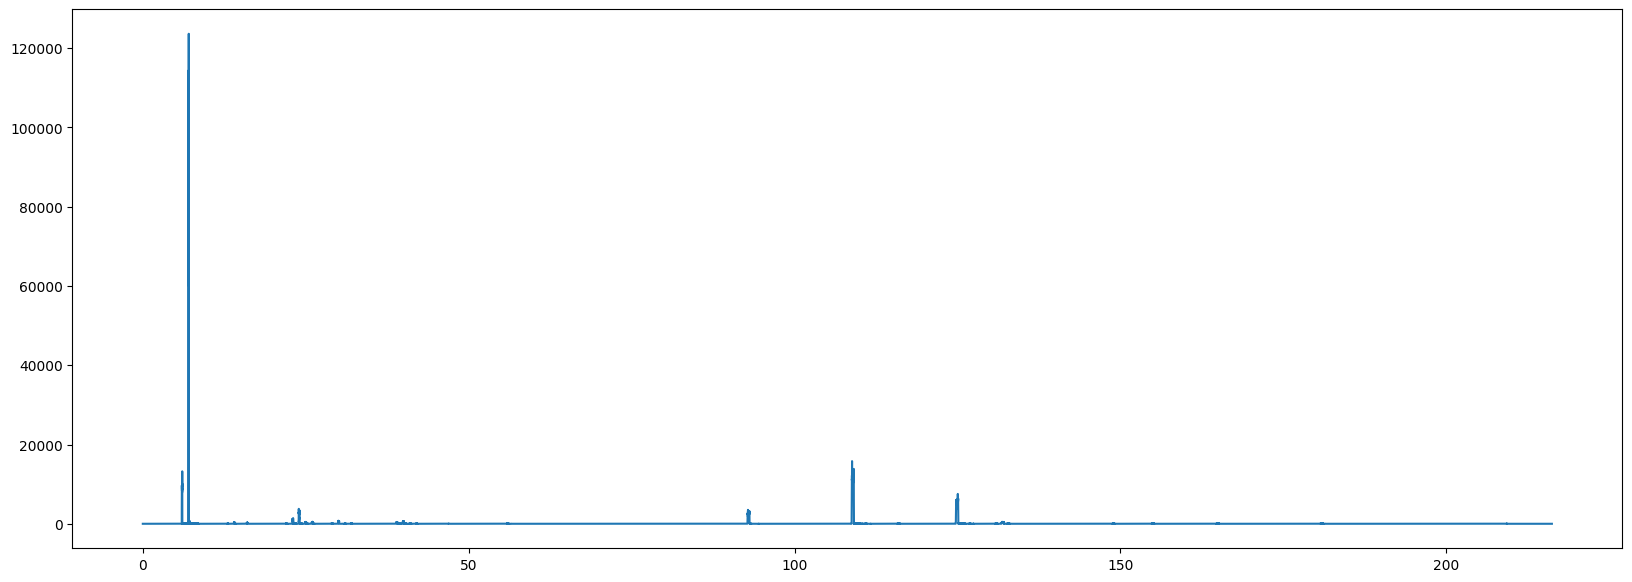

In [2]:
import pySPM
print(pySPM.__version__)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline

import os
from IPython import display
I = pySPM.ITM("LiNbO3_position 2 BA positive depth.itm")
from IPython import display
masses, raw_spectrum = I.get_raw_spectrum(scans=range(2000), prog=True) # get raw spectrum of the first 10 scans
display.clear_output()

fig = plt.figure(figsize=(20,7))
plt.plot(masses, raw_spectrum);

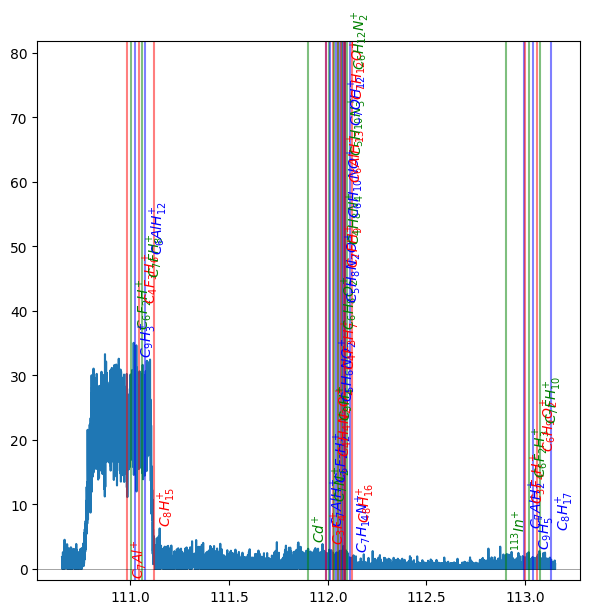

In [3]:
masses = I.channel2mass(np.arange(masses.size))

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
pySPM.utils.showPeak(masses, raw_spectrum,'Cd', 1.25, ax=ax, polarity='+')

In [4]:

import os as os 
import numpy as np
name = 'Cdl10'
files = os.listdir(name)
files.sort()
files = [file for file in files if file.endswith('.npy')]
data = [[] for i in range(len(files)*10)]
for i in range(len(files)):
    for k in range(10):
        data[i*10+k] = np.load(name+'/'+files[i])[k][0]
        
data = np.array(data)
data.shape


(2040, 256, 256)

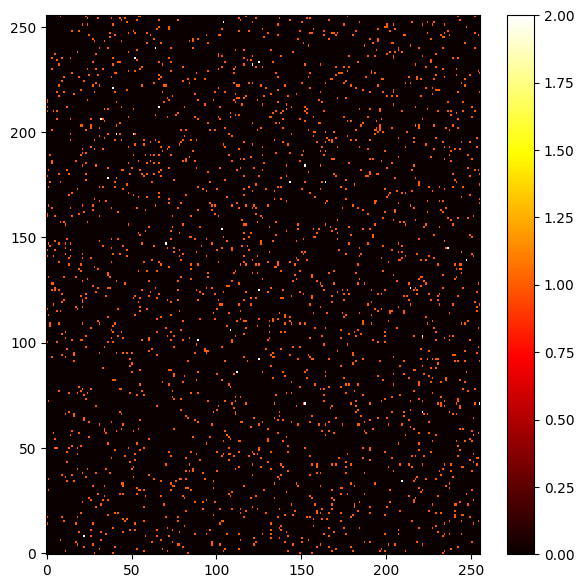

In [5]:
test = []
numberofcuts = 5
length = len(data)
f = round(length/numberofcuts)

for i in range(numberofcuts):
    # add data i to i+10 up 
    test.append(np.sum(data[i*f:i*f+f], axis=0))
# print the shape of tes
ax, fig = plt.subplots(figsize=(7,7))
plt.imshow(test[2], cmap='hot', interpolation='nearest', origin='lower', label='Cadmium', aspect='auto')
plt.colorbar()
